Total number of images (X): 1797
Total number of labels (Y): 1797
SVM training completed.
Model Accuracy: 0.8166666666666667


Saving 6 number.webp to 6 number.webp


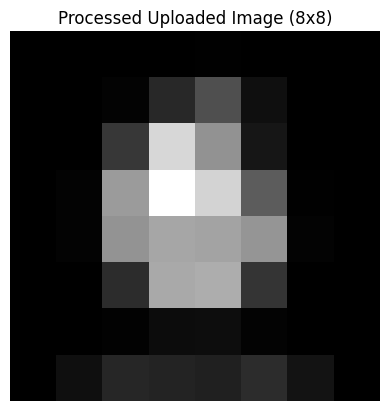

Predicted Digit: 0


In [ ]:
# Classical ML based Digit Recognition using SVM + HOG

import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from skimage.feature import hog
from skimage.transform import resize

# -------------------------------
# Load Digits Dataset
# -------------------------------
digits = datasets.load_digits()
X = digits.images
y = digits.target

print("Total number of images (X):", X.shape[0])
print("Total number of labels (Y):", y.shape[0])

# -------------------------------
# Extract HOG Features
# -------------------------------
features = []

for img in X:
    hog_feature = hog(
        img,
        pixels_per_cell=(4, 4),
        cells_per_block=(1, 1),
        orientations=9
    )
    features.append(hog_feature)

features = np.array(features)

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    features, y, test_size=0.2, random_state=42
)

# -------------------------------
# Train SVM Model
# -------------------------------
model = SVC(kernel='linear')
model.fit(X_train, y_train)

print("SVM training completed.")

# -------------------------------
# Model Accuracy
# -------------------------------
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# -------------------------------
# Upload Image (Google Colab)
# -------------------------------
from google.colab import files
uploaded = files.upload()

# -------------------------------
# Process Uploaded Image & Predict
# -------------------------------
for file_name in uploaded.keys():
    img = cv2.imread(file_name)

    # Convert to grayscale if needed
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img

    # Resize to 8x8
    img_resized = resize(img_gray, (8, 8), anti_aliasing=True)

    # Normalize
    img_resized = img_resized / img_resized.max()

    # Invert colors (to match digits dataset)
    img_resized = 1 - img_resized

    # Show processed image
    plt.imshow(img_resized, cmap='gray')
    plt.title("Processed Uploaded Image (8x8)")
    plt.axis('off')
    plt.show()

    # Extract HOG features
    test_feature = hog(
        img_resized,
        pixels_per_cell=(4, 4),
        cells_per_block=(1, 1),
        orientations=9
    )

    # Predict digit
    prediction = model.predict([test_feature])
    print("Predicted Digit:", prediction[0])


Total number of images: 1797
Image shape: (8, 8)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 6, 6, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,466 (76.04 KB)

 Trainable params: 19,466 (76.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3052 - loss: 2.2244 - val_accuracy: 0.7014 - val_loss: 1.8385
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6845 - loss: 1.6633 - val_accuracy: 0.8333 - val_loss: 1.1031
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8353 - loss: 0.9467 - val_accuracy: 0.8750 - val_loss: 0.5692
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9028 - loss: 0.5347 - val_accuracy: 0.8819 - val_loss: 0.4139
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9313 - loss: 0.3447 - val_accuracy: 0.9236 - val_loss: 0.3413
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9324 - loss: 0.3044 - val_accuracy: 0.9236 - val_loss: 0.2585
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9393 - loss: 0.2250 - val_accuracy: 0.9375 - val_loss: 0.2264
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9594 - loss: 0.1793 - val_accuracy: 0.9444 - v

Saving 6 number.webp to 6 number (1).webp


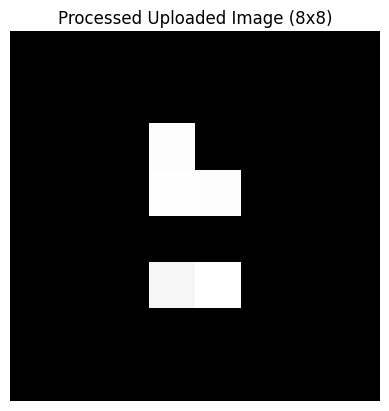

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Predicted Digit: 4


In [ ]:
# ==========================================
# CNN Based Digit Recognition (8x8 Digits)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn import datasets
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# -------------------------------
# Load Digits Dataset
# -------------------------------
digits = datasets.load_digits()

X = digits.images
y = digits.target

print("Total number of images:", X.shape[0])
print("Image shape:", X.shape[1:])

# -------------------------------
# Preprocess Data
# -------------------------------

# Normalize (digits dataset range: 0–16)
X = X / 16.0

# Reshape for CNN: (N, 8, 8, 1)
X = X.reshape(-1, 8, 8, 1)

# One-hot encode labels
y = to_categorical(y, num_classes=10)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Build CNN Model
# -------------------------------
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -------------------------------
# Train Model
# -------------------------------
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# -------------------------------
# Evaluate Model
# -------------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_accuracy)

# -------------------------------
# Upload Image (Google Colab)
# -------------------------------
from google.colab import files
uploaded = files.upload()

# -------------------------------
# Process Uploaded Image & Predict
# -------------------------------
for file_name in uploaded.keys():
    img = cv2.imread(file_name)

    # Convert to grayscale
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize to 8x8
    img_resized = cv2.resize(img_gray, (8, 8))

    # Normalize
    img_resized = img_resized / img_resized.max()

    # Invert colors to match dataset
    img_resized = 1 - img_resized

    # Display processed image
    plt.imshow(img_resized, cmap='gray')
    plt.title("Processed Uploaded Image (8x8)")
    plt.axis('off')
    plt.show()

    # Prepare for CNN
    img_input = img_resized.reshape(1, 8, 8, 1)

    # Predict
    prediction = model.predict(img_input)
    predicted_digit = np.argmax(prediction)

    print("Predicted Digit:", predicted_digit)
